Imamo sobo z določenim številom polj. Širina in višina sta gotovo manjši od 10, nista pa nujno enaki. Med nekaterimi polji so postavljene ovire. Ovire opišemo s trojkami `(smer,​x,​y)`, kjer je smer `"|"` ali `"-"`, `x` in `y` pa sta koordinati levega spodnjega oglišča ovire. Ena od ovir je narisana črtkano: ta je predstavljena z `("|",​2,​3)`. Ovire na sliki opišemo z množico `{('|',​1,​0), ('-',​0,​3), ('-',​1,​2), ('-',​1,​5), ('-',​3,​1), ('|',​3,​1), ('|',​5,​5), ('-',​5,​4), ('|',​3,​4), ('|',​5,​1), ('-',​3,​5),  ('|',​4,​2), ('|',​2,​3), ('-',​2,​2), ('|',​3,​3)}`.

Polja označujemo s koordinato levega spodnjega oglišča. Pot, zarisana na sliki, se, recimo, začne na polju `(3, 5)`.

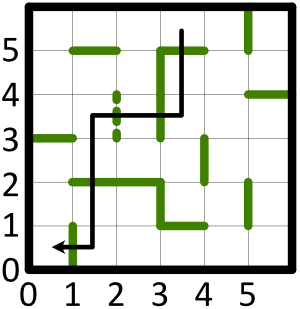

## 1. Branje ovir

Napišite funkcijo `ovire(s)`, ki prejme niz, ki opisuje ovire v takšni obliki: `"|12 -34 -52 |78"`. Smeri ovire sledita
koordinata x in nato koordinata `y`; ovire so ločene s presledki. Vrniti mora množico z opisi ovir, torej, v tem primeru,
`{('|',1,2), ('-',3,4), ('-',5,2), ('|',7,8)}`.

Potem pa napišite še funkcijo `zapis(ovire)`, ki naredi obratno: prejme množico ovir in vrne niz.

Da dobite vse točke, morata biti funkciji napisani v eni vrstici z uporabo generatorjev oziroma izpeljanih množic.

### Rešitev

Tole je bila očitno naloga iz dela z nizi, zraven pa iz množic (no: sestavljanja množic) in generatorjev.

V več vrsticah naredimo tako.

In [1]:
def ovire(s):
    vse_ovire = set()
    for ovira in s.split():
        vse_ovire.add((ovira[0], int(ovira[1]), int(ovira[2])))
    return vse_ovire

V eni, tako.

In [2]:
def ovire(s):
    return {(ovira[0], int(ovira[1]), int(ovira[2])) for ovira in s.split()}

Tako pa v drugo stran.

In [3]:
def zapis(ovire):
    return " ".join(f"{smer}{x}{y}" for smer, x, y in ovire)

## 2. Glodanje

Napišite funkcijo `glodanje(pot, ovire)`, ki prejme pot v obliki iz domačih nalog in vrne število ovir, ki jih
pregloda glodalec na tej poti. Pot se začne na `(0, 0)`.

Za pot `"^>v<"` in ovire z gornje slike pregloda eno oviro (namreč `("|",1,0)`, z desne).

Klic `glodanje(">^^^>>^^", ovire)` (obratna pot s slike) vrne 5, ker je na tej poti pet ovir. Klic `glodanje("><><>", ovire)` vrne 1, saj vsako oviro pregloda le enkrat in jo tudi štejemo le enkrat.

Funkcija ne sme spremeniti množice, ki jo je dobila kot argument!

### Rešitev

To je samo naloga iz "splošne spretnosti". Predvsem je trik v tem, da lahko oviro preglodamo z leve ali z desne -- temu je služil primer, ki je namerno vodil okrog ovire in jo preglodal z druge strani.

Hkrati gre za nalogo iz "referenc", torej tistih "puščic" s predavanja. Navodilo namreč jasno zahteva, da ne spremenimo množice, ki smo jo dobili kot argument.

Najprepresteje jo rešimo tako,

In [4]:
def glodanje(pot, ovire):
    x = y = 0
    preostale = ovire.copy()
    for korak in pot:
        dx, dy, smer = d[korak]
        preostale.discard((smer, max(x, x + dx), max(y, y + dy)))
        x += dx
        y += dy
    return len(ovire) - len(preostale)

V `preostale` skopiramo množico ovir. Nato hodimo po sobi, kot smo se čez leto navadili početi s sesalcem in iz `preostale` pobrišemo vse morebitne preglodane ovire. Na koncu preverimo, koliko je množica preostalih ovir manjša od množice začetnih.

Glavni trik je v vrstici z `discard` (namesto tega lahko uporabimo tudi `remove` ali kak drug način odstranjevanja elementov iz množic). Navpične ovire imajo vedno koordinate desnega polja: če je ovira med poljema (5, 3) in (6, 3), so njena kooridnate (6, 3), pa če gremo iz (5, 3) na (6, 3) ali iz (6, 3) na (5, 3). Podobno imajo vodoravne ovire vedno koordinato gornjega polja. Zato koordinate ovire določimo z `max` med koordinatami polj, med katerima smo naredili premik.

## 3. Naj glodalec
V tej nalogi glodalec začne pot na določenem polju in potuje do polja (0, 0), pri čemer pa se lahko premika le levo
in dol. Glodalci radi glodajo, zato je potrebno poiskati pot, ki vsebuje čimveč ovir.

Napišite torej funkcijo `naj_glodalec(x, y, ovire)`, ki vrne največje število ovir, ki jih lahko pregloda glodalec,
ki začne na podanem polju. Klic `naj_glodalec(3, 5, ovire)` vrne `5`, ker lahko glodalec, ki začne na `(3, 5)`
pregloda največ 5 ovir. Eno od dveh možnih poti, ki vsebujeta takšno število ovir, kaže slika.

Lahko si pomagate s podano funkcijo `je_oviran(x, y, smer, ovire)`, ki pove, ali je oviran prehod s polja `(x,
y)` navzdol (če je smer enaka `"-"`) oziroma levo (če je smer `"|"`). Klic `je_oviran(3, 5, "-", ovire)` vrne `True`,
ker je pot s `(3, 5)` navzdol ovirana. Klic `je_oviran(3, 5, "|", ovire)` vrne `False`, ker pot s 3, 5 na levo ni
ovirana. (Funkcija je trivialna; podana je bolj kot namig, kako se lotiti.)

Naloga je lažja, kot se zdi. Preveriti morate le, koliko ovir lahko nabere, če gre na levo, in koliko, če gre dol - če
seveda ni že na levem oz. spodnjem robu.

### Rešitev

Tole je bila očitno naloga iz rekurzije.

Rešitev je v zadnjem stavku navodil (res sem se vam trudil pomagati!): "*Preveriti morate le, koliko ovir lahko nabere, če gre na levo, in koliko, če gre dol - če seveda ni že na levem oz. spodnjem robu.*"

In [6]:
def naj_glodalec(x, y, ovire):
    naj = 0
    if x > 0:
        naj = je_oviran(x, y, "|", ovire) + naj_glodalec(x - 1, y, ovire)
    if y > 0:
        naj = max(naj, je_oviran(x, y, "-", ovire) + naj_glodalec(x, y - 1, ovire))
    return naj

`je_oviran` sicer vrača `True` in `False`, vendar smemo to razumeti, kot da vrne `1`, če je glodalec oviran v podani smeri, in `0`, če ni.

Če gre levo, bo na svoji poti nabral še (največ) `naj_glodalec(x - 1, y, ovire)`, k čemur prištejemo `je_oviran`. Podobno v smeri dol.

Če hočemo, lahko nalogo rešimo tudi krajše:

In [7]:
def naj_glodalec(x, y, ovire):
    return max(x > 0 and je_oviran(x, y, "|", ovire) + naj_glodalec(x - 1, y, ovire),
               y > 0 and je_oviran(x, y, "-", ovire) + naj_glodalec(x, y - 1, ovire))

## 4. Soba

Napišite razred Soba z naslednjimi metodami.

- Konstruktor prejme širino in višino (v številu polj - za primer iz slike je to 6!) ter pripravi vse, kar je potrebno
za delovanje objekta.
- `dodaj_oviro(smer, x, y)` doda oviro v podani smeri na podane koordinate - vendar le, če tam še ni ovire in če se ovira nahaja znotraj sobe (ne izven ali morda v steni sobe). Če doda oviro, vrne `True`; če jo zavrne, `False`.
- `odstrani_oviro(smer, x, y)`; če podana ovira obstaja, vrne `True` in jo odstrani. Sicer vrne `False`.
- `stevilo_ovir()` vrne število ovir v sobi.
- `ovire_polja(x, y)` vrne množico, ki vsebuje opise vseh ovir na robovih podanega polja (torej 0-4 ovir).

## Rešitev

Tule je potrebno le pravilno definirati razred in popaziti na kakšen pogoj. Večina s tem ni imela večjih problemov.

In [8]:
class Soba:
    def __init__(self, sirina, visina):
        self.sirina = sirina
        self.visina = visina
        self.ovire = set()

    def dodaj_oviro(self, smer, x, y):
        ovira = (smer, x, y)
        if ovira not in self.ovire \
                and (smer == "|") <= x < self.sirina \
                and (smer == "-") <= y < self.visina:
            self.ovire.add((smer, x, y))
            return True
        else:
            return False

    def odstrani_oviro(self, smer, x, y):
        ovira = (smer, x, y)
        if ovira in self.ovire:
            self.ovire.remove((smer, x, y))
            return True
        else:
            return False

    def stevilo_ovir(self):
        return len(self.ovire)

    def ovire_polja(self, x, y):
        return self.ovire & {('|', x, y), ('-', x, y), ('-', x, y + 1), ('|', x + 1, y)}


Če koga motijo tisti zoprni `return True`, `return False`, lahko naredi metodo `dodaj_oviro` tudi tako

In [9]:
    def dodaj_oviro(self, smer, x, y):
        ovira = (smer, x, y)
        ok = ovira not in self.ovire \
                and (smer == "|") <= x < self.sirina \
                and (smer == "-") <= y < self.visina
        if ok:
            self.ovire.add((smer, x, y))
        return ok

Ali celo tako:

In [10]:
    def dodaj_oviro(self, smer, x, y):
        ovira = (smer, x, y)
        if ok := ovira not in self.ovire \
                and (smer == "|") <= x < self.sirina \
                and (smer == "-") <= y < self.visina:
            self.ovire.add((smer, x, y))
        return ok

Metodo `odstrani_oviro` pa prav tako:

In [11]:
    def odstrani_oviro(self, smer, x, y):
        ovira = (smer, x, y)
        if ok := ovira in self.ovire:
            self.ovire.remove((smer, x, y))
        return ok